In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tbyrnes/advertising")

print("Path to dataset files:", path)

Path to dataset files: /Users/hunter.lybbert/.cache/kagglehub/datasets/tbyrnes/advertising/versions/1


In [2]:
import pandas as pd

In [3]:
raw_df = pd.read_csv("/Users/hunter.lybbert/.cache/kagglehub/datasets/tbyrnes/advertising/versions/1/advertising.csv")
raw_df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [4]:
raw_df.rename(columns=lambda x:x.replace(' ', '_').lower(),inplace=True)
raw_df.columns

Index(['daily_time_spent_on_site', 'age', 'area_income',
       'daily_internet_usage', 'ad_topic_line', 'city', 'male', 'country',
       'timestamp', 'clicked_on_ad'],
      dtype='str')

In [5]:
df = raw_df.copy(deep=True)
df.timestamp = pd.to_datetime(df.timestamp)
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["hour"] = df["timestamp"].dt.hour
df["month"] = df["timestamp"].dt.month
df.drop(columns=["timestamp"], inplace=True)
df.dtypes

daily_time_spent_on_site    float64
age                           int64
area_income                 float64
daily_internet_usage        float64
ad_topic_line                   str
city                            str
male                          int64
country                         str
clicked_on_ad                 int64
day_of_week                   int32
hour                          int32
month                         int32
dtype: object

In [6]:
# age -> daily_time_spent_on_site;
# age -> daily_internet_usage;
# male -> daily_internet_usage;
# male -> daily_time_spent_on_site;
# daily_time_spent_on_site -> timestamp;
# daily_internet_usage -> timestamp;
# daily_time_spent_on_site -> clicked_on_ad;
# daily_internet_usage -> clicked_on_ad;
# country -> area_income -> clicked_on_ad;
# country -> daily_internet_usage;
# area_income -> daily_time_spent_on_site;
# area_income -> daily_internet_usage;
# area_income -> clicked_on_ad;
# city -> country -> area_income -> clicked_on_ad;
# city -> area_income;

# 'daily_internet_usage',
# 'ad_topic_line',
# 'city',
# 'male',
# 'country',
# 'timestamp',
# 'clicked_on_ad'

In [20]:
causal_graph = """
digraph {
daily_time_spent_on_site;
age;
area_income;
daily_internet_usage;
ad_topic_line;
city;
male;
country;
day_of_week;
hour;
month;
clicked_on_ad;
age -> daily_time_spent_on_site;
age -> daily_internet_usage;
male -> daily_internet_usage;
male -> daily_time_spent_on_site;
daily_time_spent_on_site -> day_of_week;
daily_internet_usage -> day_of_week;
daily_time_spent_on_site -> month;
daily_internet_usage -> month;
daily_time_spent_on_site -> hour;
daily_internet_usage -> hour;
country -> area_income -> clicked_on_ad;
country -> daily_internet_usage;
area_income -> daily_time_spent_on_site;
area_income -> daily_internet_usage;
area_income -> clicked_on_ad;
city -> country -> area_income -> clicked_on_ad;
city -> area_income;
day_of_week -> clicked_on_ad;
hour -> clicked_on_ad;
month -> clicked_on_ad;
}
"""
# ad_topic_line -> clicked_on_ad;

In [21]:
from dowhy import CausalModel

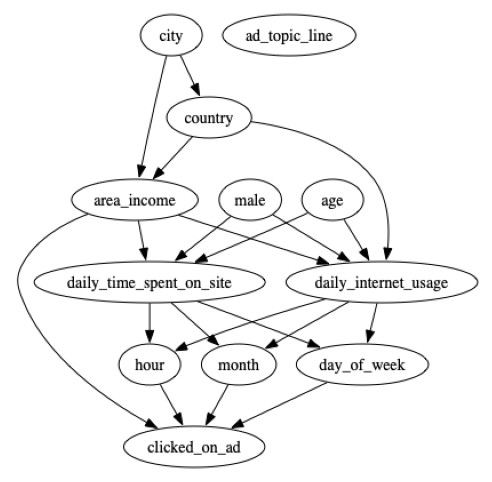

In [22]:
model = CausalModel(
    data=df,
    graph=causal_graph.replace("\n", " "),
    treatment="hour",
    outcome="clicked_on_ad",
)
model.view_model()

In [ ]:
# df.ad_topic_line.head(25)

0                Cloned 5thgeneration orchestration
1                Monitored national standardization
2                  Organic bottom-line service-desk
3             Triple-buffered reciprocal time-frame
4                     Robust logistical utilization
5                   Sharable client-driven software
6                        Enhanced dedicated support
7                          Reactive local challenge
8                    Configurable coherent function
9                Mandatory homogeneous architecture
10                   Centralized neutral neural-net
11    Team-oriented grid-enabled Local Area Network
12            Centralized content-based focus group
13                 Synergistic fresh-thinking array
14                    Grass-roots coherent extranet
15               Persistent demand-driven interface
16               Customizable multi-tasking website
17                       Intuitive dynamic attitude
18     Grass-roots solution-oriented conglomeration
19          

In [24]:
# model = CausalModel(
#     data=df,
#     graph=causal_graph.replace("\n", " "),
#     treatment="timestamp",
#     outcome="clicked_on_ad",
# )
# model.view_model()

In [25]:
estimands = model.identify_effect()
print(estimands)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                                   
───────(E[clicked_on_ad|daily_internet_usage,daily_time_spent_on_site])
d[hour]                                                                
Estimand assumption 1, Unconfoundedness: If U→{hour} and U→clicked_on_ad then P(clicked_on_ad|hour,daily_internet_usage,daily_time_spent_on_site,U) = P(clicked_on_ad|hour,daily_internet_usage,daily_time_spent_on_site)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
   d                                                                   
───────(E[clicked_on_ad|daily_internet_usage,daily_time_spent_on_site])
d[hour]                                                                
Estimand assumption 1, Unconfounded

In [27]:
estimate = model.estimate_effect(
    identified_estimand=estimands,
    method_name="backdoor.linear_regression",
    # method_name="backdoor.econml.dml.CausalForestDML",
    confidence_intervals=True,
    test_significance=True,
    # method_params={
    #     "init_params": {
    #         "n_estimators": 100,
    #         "random_state": 42
    #     }
    # }
)

print(f'Estimate of causal effect: {estimate}')

Estimate of causal effect: *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                                                   
───────(E[clicked_on_ad|daily_internet_usage,daily_time_spent_on_site])
d[hour]                                                                
Estimand assumption 1, Unconfoundedness: If U→{hour} and U→clicked_on_ad then P(clicked_on_ad|hour,daily_internet_usage,daily_time_spent_on_site,U) = P(clicked_on_ad|hour,daily_internet_usage,daily_time_spent_on_site)

## Realized estimand
b: clicked_on_ad~hour+daily_internet_usage+daily_time_spent_on_site+hour*day_of_week+hour*month
Target units: 

## Estimate
Mean value: -0.00046934978493284873
p-value: [0.74907975]
95.0% confidence interval: (np.float64(-0.002546200086192607), np.float64(0.0018146626893807971))
### Conditional Estimates
__categorical__day_of_week  __categorical__month
(-0.0

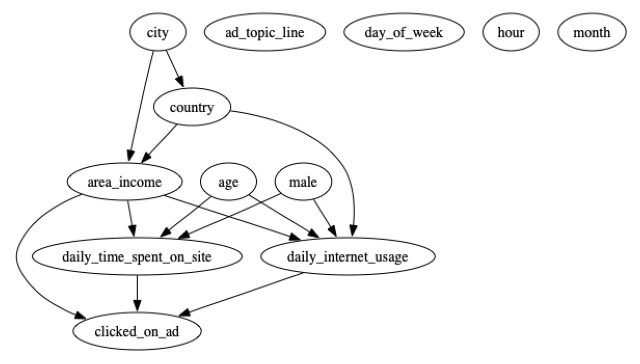

In [32]:
causal_graph_updated = """
digraph {
daily_time_spent_on_site;
age;
area_income;
daily_internet_usage;
ad_topic_line;
city;
male;
country;
day_of_week;
hour;
month;
clicked_on_ad;
age -> daily_time_spent_on_site;
age -> daily_internet_usage;
male -> daily_internet_usage;
male -> daily_time_spent_on_site;
daily_time_spent_on_site -> clicked_on_ad;
daily_internet_usage -> clicked_on_ad;
country -> area_income -> clicked_on_ad;
country -> daily_internet_usage;
area_income -> daily_time_spent_on_site;
area_income -> daily_internet_usage;
area_income -> clicked_on_ad;
city -> country -> area_income -> clicked_on_ad;
city -> area_income;
}
"""
# ad_topic_line -> clicked_on_ad;

model_updated = CausalModel(
    data=df,
    graph=causal_graph_updated.replace("\n", " "),
    treatment="daily_internet_usage",
    outcome="clicked_on_ad",
)
model_updated.view_model()

In [33]:
estimands_updated = model_updated.identify_effect()
print(estimands_updated)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
           d                                                                  
───────────────────────(E[clicked_on_ad|area_income,daily_time_spent_on_site])
d[daily_internet_usage]                                                       
Estimand assumption 1, Unconfoundedness: If U→{daily_internet_usage} and U→clicked_on_ad then P(clicked_on_ad|daily_internet_usage,area_income,daily_time_spent_on_site,U) = P(clicked_on_ad|daily_internet_usage,area_income,daily_time_spent_on_site)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
           d                                                  
───────────────────────(E[clicked_on_ad|age,area_income,male])
d[daily_internet_usage]                                       
Estimand as

In [34]:
estimate = model_updated.estimate_effect(
    identified_estimand=estimands_updated,
    method_name="backdoor.linear_regression",
    # method_name="backdoor.econml.dml.CausalForestDML",
    confidence_intervals=True,
    test_significance=True,
    # method_params={
    #     "init_params": {
    #         "n_estimators": 100,
    #         "random_state": 42
    #     }
    # }
)

print(f'Estimate of causal effect: {estimate}')

Estimate of causal effect: *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
           d                                                                  
───────────────────────(E[clicked_on_ad|area_income,daily_time_spent_on_site])
d[daily_internet_usage]                                                       
Estimand assumption 1, Unconfoundedness: If U→{daily_internet_usage} and U→clicked_on_ad then P(clicked_on_ad|daily_internet_usage,area_income,daily_time_spent_on_site,U) = P(clicked_on_ad|daily_internet_usage,area_income,daily_time_spent_on_site)

## Realized estimand
b: clicked_on_ad~daily_internet_usage+area_income+daily_time_spent_on_site+daily_internet_usage*daily_time_spent_on_site
Target units: 

## Estimate
Mean value: -0.005637221868382003
p-value: [0.41300316]
95.0% confidence interval: (np.float64(-0.006068843513229671), np.float64(-0.005152822316435213))
### Co

In [35]:
model_updated_2 = CausalModel(
    data=df,
    graph=causal_graph_updated.replace("\n", " "),
    treatment="daily_time_spent_on_site",
    outcome="clicked_on_ad",
)

estimands_updated = model_updated_2.identify_effect()
print(estimands_updated)

estimate = model_updated_2.estimate_effect(
    identified_estimand=estimands_updated,
    method_name="backdoor.linear_regression",
    # method_name="backdoor.econml.dml.CausalForestDML",
    confidence_intervals=True,
    test_significance=True,
    # method_params={
    #     "init_params": {
    #         "n_estimators": 100,
    #         "random_state": 42
    #     }
    # }
)

print(f'Estimate of causal effect: {estimate}')

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
            d                                                                
──────────────────────────(E[clicked_on_ad|area_income,daily_internet_usage])
d[dailyₜᵢₘₑ ₛₚₑₙₜ ₒₙ ₛᵢₜₑ]                                                   
Estimand assumption 1, Unconfoundedness: If U→{daily_time_spent_on_site} and U→clicked_on_ad then P(clicked_on_ad|daily_time_spent_on_site,area_income,daily_internet_usage,U) = P(clicked_on_ad|daily_time_spent_on_site,area_income,daily_internet_usage)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
            d                                                    
──────────────────────────(E[clicked_on_ad|age,area_income,male])
d[dailyₜᵢₘₑ ₛₚₑₙₜ ₒₙ ₛᵢₜₑ]                                       
E

Start here by refuting the estimates that you developed, rework naming from the top so it is clear which models, graphs, and estimates/estimands are from which version of the modeling setup.

In [ ]:
# From Claude:
# 1. Placebo treatment refuter — randomizes the treatment; a real effect should vanish.
#    Most diagnostic given your CI/p-value disagreement: if a *placebo* treatment also
#    produces a "significant"-looking estimate under this same estimator, the significance
#    test itself is unreliable, not just this particular result.
res_placebo = model_updated.refute_estimate(
    estimands_updated,
    estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    num_simulations=100,
)
print(res_placebo)

# 2. Random common cause — adds an independent random covariate as a confounder.
#    A robust estimate should barely move.
res_random_cc = model_updated.refute_estimate(
    estimands_updated,
    estimate,
    method_name="random_common_cause",
    num_simulations=100,
)
print(res_random_cc)

# 3. Data subset refuter — refits on random subsets of the data.
#    A stable effect should stay close to the full-sample estimate across subsets.
res_subset = model_updated.refute_estimate(
    estimands_updated,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=100,
)
print(res_subset)


SyntaxError: invalid syntax (3983541303.py, line 1)